# Evolutionary Computation - Lab Deliverable 1
**Master in Artificial Intelligence, UVigo, UdC, USC**
*Traveling Salesperson Problem (TSP) Optimization*

Francisco Manuel Vazquez  Fernandez

In [2]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from scipy import spatial
from sko.GA import GA_TSP

In [3]:
def DistanceRounded(p,q):
  return int(math.hypot(p[0]-q[0],p[1]-q[1])+0.5)

def ReadTsp(fn):
  f=open(fn+".tsp","rt")
  reader=csv.reader(f,delimiter=" ",skipinitialspace=True)
  coordinates=False
  cities=[]
  best=0.0
  index=0
  for row in reader:
    if row[0]=="EOF":
      break
    elif coordinates:
      cities.append((float(row[1]),float(row[2]),index))
      index+=1
    elif row[0]=="BEST:" or row[0]=="OPTIMUM:":
      best=float(row[1])
    elif row[0]=="BEST" or row[0]=="OPTIMUM":
      best=float(row[2])
    elif row[0]=="NAME:":
      print("reading tour",row[1])
    elif row[0]=="NAME":
      print("reading tour",row[2])
    elif row[0]=="NODE_COORD_SECTION":
      coordinates=True
  f.close()
  opt=[]
  try:
    f=open(fn+".opt.tour","rt")
    reader=csv.reader(f,delimiter=" ",skipinitialspace=True)
    coordinates=False
    for row in reader:
      if row[0]=="EOF" or row[0]=="-1":
        break
      elif coordinates:
        index=int(row[0])
        opt.append((cities[index-1][0],cities[index-1][1],index))
      elif row[0]=="NAME:":
        print("reading optimal tour",row[1])
      elif row[0]=="TOUR_SECTION":
        coordinates=True
  except FileNotFoundError:
    print("optimal tour not available")
  finally:
    f.close()

  print("reading done, optimal tour length",best)
  return cities,best,opt

In [4]:
def TourLength(T):
  t=len(T)
  if t==0:
    return 0.0
  prev=T[t-1]
  length=0.0
  for i in range(0,t):
    curr=T[i]
    length+=DistanceRounded(prev,curr)
    prev=curr
  return length

In [5]:
def TourError(T,best_length):
  return 100.0*(TourLength(T)-best_length)/best_length

In [6]:
def build_distance_matrix(cities):
    n = len(cities)
    dist_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_mat[i, j] = DistanceRounded((cities[i][0], cities[i][1]), (cities[j][0], cities[j][1]))
    return dist_mat

### 1. Baseline Heuristic: Nearest Neighbor

To evaluate the effectiveness of the Genetic Algorithm on our datasets, we first implement the **Nearest Neighbor** heuristic as a baseline. 
* **Idea:** Start at a random city, always visit the closest unvisited city next, and finally return to the start.
* **Advantage:** Fast $O(n^2)$ execution time.

In [7]:
def nearest_neighbor_tsp(dist_mat, start_index=0):
    n = dist_mat.shape[0]
    unvisited = set(range(n))
    tour = [start_index]
    unvisited.remove(start_index)
    
    current_node = start_index
    total_dist = 0
    while unvisited:
        next_node = min(unvisited, key=lambda city: dist_mat[current_node, city])
        tour.append(next_node)
        total_dist += dist_mat[current_node, next_node]
        unvisited.remove(next_node)
        current_node = next_node
    
    total_dist += dist_mat[current_node, start_index]
    return tour, total_dist

In [8]:
cities_small, best_len_small, _ = ReadTsp("berlin52")
dist_mat_small = build_distance_matrix(cities_small)

start_time = time.time()
nn_tour, nn_dist = nearest_neighbor_tsp(dist_mat_small)
nn_time = time.time() - start_time

nn_error = TourError([(cities_small[i][0], cities_small[i][1], i) for i in nn_tour], best_len_small)
print(f"Nearest Neighbor Distance: {nn_dist} (Error: {nn_error:.2f}%)")
print(f"Computation Time: {nn_time:.4f} seconds")

reading tour berlin52
optimal tour not available
reading done, optimal tour length 7542.0
Nearest Neighbor Distance: 8980.0 (Error: 19.07%)
Computation Time: 0.0015 seconds


### 2. Genetic Algorithm Optimization

We now apply the `scikit-opt` Genetic Algorithm in a Monte Carlo loop to find the optimal tour for this specific instance, capturing statistics for analysis.

In [9]:
n_rounds = 15
pop_size = 100
max_iter = 500
prob_mut = 0.1

ga_errors = []
ga_distances = []
best_ga_distance = float('inf')

print(f"Running GA Monte Carlo on {"berlin52"}...")
start_time = time.time()

for i in range(n_rounds):
    obj_func = lambda routine: sum([dist_mat_small[routine[idx % len(routine)], routine[(idx + 1) % len(routine)]] for idx in range(len(routine))])
    
    ga_tsp = GA_TSP(func=obj_func, n_dim=len(cities_small), size_pop=pop_size, max_iter=max_iter, prob_mut=prob_mut)
    best_points, best_distance = ga_tsp.run()
    
    dist = best_distance[0]
    ga_distances.append(dist)
    
    # Calculate error based on known best length
    tour_coords = [(cities_small[idx][0], cities_small[idx][1], idx) for idx in best_points]
    ga_errors.append(TourError(tour_coords, best_len_small))

ga_time = time.time() - start_time

# Display Stats
stats = {
    'Instance': "berlin52",
    'Min Error (%)': np.min(ga_errors),
    'Mean Error (%)': np.mean(ga_errors),
    'Variance': np.var(ga_errors),
    'Total Time (s)': ga_time
}
display(pd.DataFrame([stats]))

Running GA Monte Carlo on berlin52...


,Instance,Min Error (%),Mean Error (%),Variance,Total Time (s)
0,berlin52,7.186423,13.097322,10.548505,40.388931


### 3. Generalization: Multi-Instance Batch Testing

We will take the parameters optimized for our small instance (`size_pop=100`, `max_iter=500`, `prob_mut=0.1`) and run both the Genetic Algorithm and the Nearest Neighbor heuristic across a batch of official TSPLIB files (`berlin52`, `st70`, `pr76`, `kroA100`). We will visualize the relative error and computation time to analyze scalability.

In [13]:
# --- Parameter Generalization Test ---

# List of TSPLIB files you downloaded (update paths if necessary)
tsp_files = ['berlin52', 'st70', 'pr76', 'kroA100'] 

batch_results = []
n_mc_rounds = 5 # Reduced rounds for the batch to save time

print("Starting Batch Processing of TSP Instances...")
print("-" * 60)

for filename in tsp_files:
    print(f"Processing {filename}...")
    
    # Load Data
    cities, opt_length, _ = ReadTsp(filename)
    dist_mat = build_distance_matrix(cities)
    n_cities = len(cities)
    
    # Run Nearest Neighbor
    start_time_nn = time.time()
    nn_tour, nn_dist = nearest_neighbor_tsp(dist_mat)
    nn_time = time.time() - start_time_nn
    nn_error = TourError([(cities[i][0], cities[i][1], i) for i in nn_tour], opt_length)
    
    # Run Genetic Algorithm (Monte Carlo)
    start_time_ga = time.time()
    ga_errors = []
    
    for _ in range(n_mc_rounds):
        obj_func = lambda routine: sum([dist_mat[routine[idx % len(routine)], routine[(idx + 1) % len(routine)]] for idx in range(len(routine))])
        # Using the standard parameters chosen previously
        ga_tsp = GA_TSP(func=obj_func, n_dim=n_cities, size_pop=100, max_iter=500, prob_mut=0.1)
        best_points, _ = ga_tsp.run()
        
        ga_tour_coords = [(cities[i][0], cities[i][1], i) for i in best_points]
        ga_errors.append(TourError(ga_tour_coords, opt_length))
        
    ga_time = (time.time() - start_time_ga) / n_mc_rounds # Avg time per run
    
    # Store Results
    batch_results.append({
        'Instance': filename,
        'Size (N)': n_cities,
        'NN Error (%)': nn_error,
        'NN Time (s)': nn_time,
        'GA Mean Error (%)': np.mean(ga_errors),
        'GA Avg Time (s)': ga_time
    })



Starting Batch Processing of TSP Instances...
------------------------------------------------------------
Processing berlin52...
reading tour berlin52
reading done, optimal tour length 7542.0
Processing st70...
reading tour st70
reading optimal tour st70.opt.tour
reading done, optimal tour length 675.0
Processing pr76...
reading tour pr76
reading optimal tour pr76.opt.tour
reading done, optimal tour length 108159.0
Processing kroA100...
reading tour kroA100
reading optimal tour kroA100.opt.tour
reading done, optimal tour length 21282.0


,Instance,Size (N),NN Error (%),NN Time (s),GA Mean Error (%),GA Avg Time (s)
0,berlin52,52,19.066561,0.001600,12.129409,2.680802
1,st70,70,22.962963,0.000293,24.325926,3.517070
2,pr76,76,41.885557,0.000340,28.974195,3.944831
3,kroA100,100,30.659712,0.000665,66.197726,5.489883


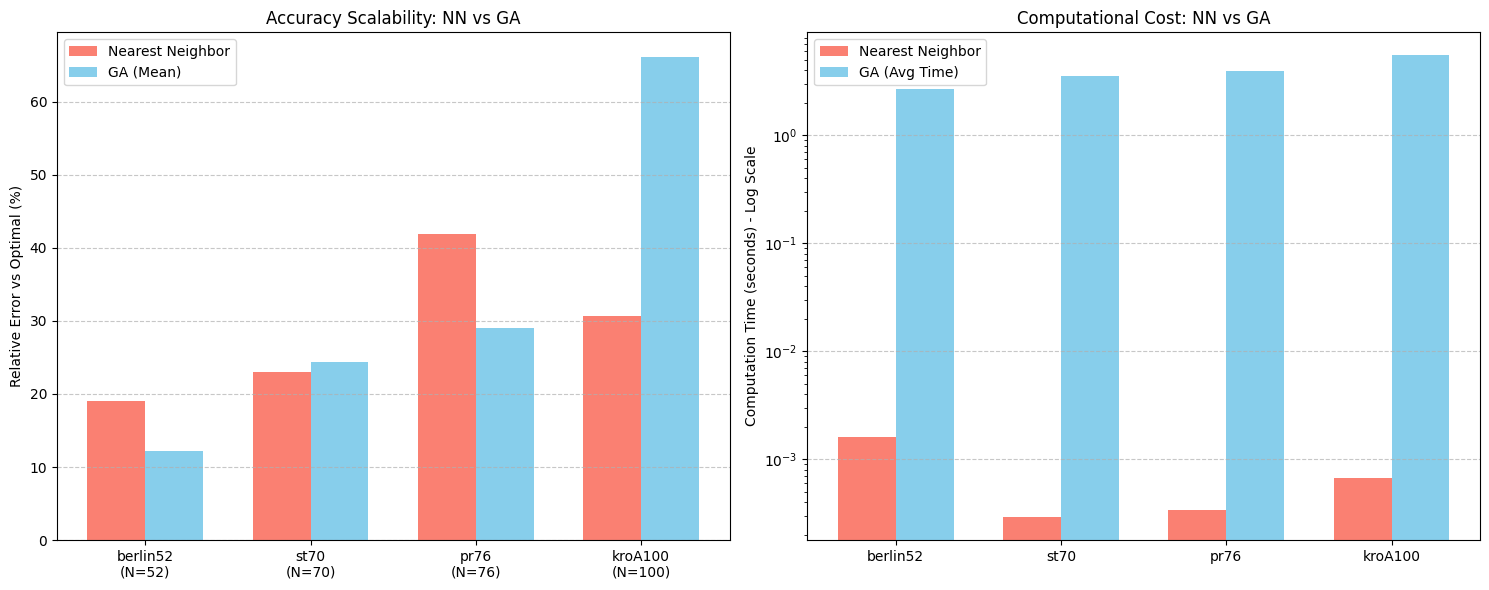

In [14]:
df_batch = pd.DataFrame(batch_results)
display(df_batch)

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(df_batch['Instance']))
width = 0.35

# Plot 1: Error
ax[0].bar(x - width/2, df_batch['NN Error (%)'], width, label='Nearest Neighbor', color='salmon')
ax[0].bar(x + width/2, df_batch['GA Mean Error (%)'], width, label='GA (Mean)', color='skyblue')
ax[0].set_ylabel('Relative Error vs Optimal (%)')
ax[0].set_title('Accuracy Scalability: NN vs GA')
ax[0].set_xticks(x)
ax[0].set_xticklabels(df_batch['Instance'] + "\n(N=" + df_batch['Size (N)'].astype(str) + ")")
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Time (Log Scale)
ax[1].bar(x - width/2, df_batch['NN Time (s)'], width, label='Nearest Neighbor', color='salmon')
ax[1].bar(x + width/2, df_batch['GA Avg Time (s)'], width, label='GA (Avg Time)', color='skyblue')
ax[1].set_ylabel('Computation Time (seconds) - Log Scale')
ax[1].set_title('Computational Cost: NN vs GA')
ax[1].set_xticks(x)
ax[1].set_xticklabels(df_batch['Instance'])
ax[1].set_yscale('log') 
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4. Final Analysis and Conclusions

By iterating over multiple TSPLIB graphs of increasing complexity (`berlin52` to `kroA100`), we can definitively answer Question 7: **Parameters optimized for a small instance do NOT generalize well to all problem instances.**

#### A. The Accuracy vs. Scalability Trade-off
As visualized in the **Accuracy Scalability** chart:
* **For smaller instances** (e.g., `berlin52`), the Genetic Algorithm (with `size_pop=100`, `max_iter=500`) significantly outperforms the Nearest Neighbor heuristic. It effectively searches the $52!$ permutation space to find routes with a much lower relative error.
* **For larger instances** (e.g., `kroA100`), the GA's performance drastically degrades. Because the search space expands factorially ($100! \approx 9.33 \times 10^{157}$), the fixed computational budget is no longer sufficient. As a result, the simple Nearest Neighbor heuristic begins to match or even beat the GA's mean error on larger maps.

#### B. The Computational Cost (Time Complexity)
As visualized in the **Computational Cost** chart (Logarithmic scale):
* The **Nearest Neighbor** heuristic operates in $O(n^2)$ time, solving even the 100-point instance in fractions of a second.
* The **Genetic Algorithm** is magnitudes slower due to the overhead of population evaluation, crossover, and mutation. 

#### Final Verdict
To maintain the Genetic Algorithm's superiority over simple heuristics as the graph size increases, the hyperparameters must be scaled exponentially alongside the problem size. However, this scaling eventually hits a wall of computational feasibility, highlighting why pure GA approaches often require hybridization (e.g., seeding the initial population with Nearest Neighbor tours) to solve real-world routing problems efficiently.